first read 
https://zhuanlan.zhihu.com/p/197888612
here are three different date set:
training set, validate set and test set

install the pytorch (have anaconda) 
:use the website command: https://pytorch.org/get-started/locally/
and pip install intel-openmp

In [8]:
# test
import torch
x = torch.rand(5, 3)
print(x)

tensor([[0.8918, 0.4683, 0.2034],
        [0.6425, 0.2303, 0.1896],
        [0.2123, 0.5893, 0.7327],
        [0.4311, 0.4565, 0.4898],
        [0.1215, 0.8817, 0.9630]])


In [9]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt


# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)


In [10]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size) #(64,1,28,28) a image of a picture 
test_dataloader = DataLoader(test_data, batch_size=batch_size) # label of every picutre, totally 64 label
# x and y consist of a training data set.
 
for X, y in test_dataloader:
    print("Shape of X [N, C, H, W]: ", X.shape)
    print("Shape of y: ", y.shape, y.dtype)
    break

Shape of X [N, C, H, W]:  torch.Size([64, 1, 28, 28])
Shape of y:  torch.Size([64]) torch.int64


In [11]:
print(X[0][0]) #(64,1,28,28) a image of a picture 
print(y)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

In [33]:
if torch.cuda.is_available():
  tensor = tensor.to('cuda')
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

Using cpu device


In [12]:
tensor = torch.ones(4, 4)
tensor[:,1] = 0            # 将第1列(从0开始)的数据全部赋值为0
print(tensor)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [16]:
# torch.cat

t1 = torch.cat([tensor, tensor], dim=1)
print(t1)
t1 = torch.cat([tensor, tensor], dim=0)
print(t1)

A = torch.tensor([[1, 2, 3],
        		  [4, 5, 6],
        		  [7, 8, 9]])
B = torch.tensor([[12, 22, 33],
        		  [44, 55, 66],
        		  [77, 88,99]])

result1 = torch.cat((A,B),0)
print("result1的维度为{}" .format(result1.dim()))
print("result1形状为{}" .format(result1.shape))
print("result1为{}" .format(result1))

result2 = torch.cat((A,B),1)
print("result2的维度为{}" .format(result2.dim()))
print("result2形状为{}" .format(result2.shape))
print("result2为{}" .format(result2))


tensor([[1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1.]])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
result1的维度为2
result1形状为torch.Size([6, 3])
result1为tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [12, 22, 33],
        [44, 55, 66],
        [77, 88, 99]])
result2的维度为2
result2形状为torch.Size([3, 6])
result2为tensor([[ 1,  2,  3, 12, 22, 33],
        [ 4,  5,  6, 44, 55, 66],
        [ 7,  8,  9, 77, 88, 99]])


In [17]:
# 一个张量内部逐个元素相乘结果
print(f"tensor.mul(tensor): \n {tensor.mul(tensor)} \n")
# 等价写法:
print(f"tensor * tensor: \n {tensor * tensor}")

# 张量与张量的矩阵乘法:
print(f"tensor.matmul(tensor.T): \n {tensor.matmul(tensor.T)} \n")
# 等价写法:
print(f"tensor @ tensor.T: \n {tensor @ tensor.T}")

tensor.mul(tensor): 
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor * tensor: 
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
tensor.matmul(tensor.T): 
 tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]]) 

tensor @ tensor.T: 
 tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])


In [19]:
# Tensor与Numpy的转化
# since numpy array and tensor share the same allocation, change one will influence the other

# creat a numpy array from the tensor
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

import numpy as np
# creat a tensor from the numpy array
n = np.ones(5)
t = torch.from_numpy(n)

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


In [26]:
# torch.chunk(input, chunks, dim=0)
# torch.split(tensor, split_size_or_sections, dim=0)

A = torch.tensor([[1, 2, 3],
        		  [4, 5, 6],
        		  [7, 8, 9]])
list_of_tensors = torch.chunk(A, dim=1, chunks=3)   # 3
for idx, t in enumerate(list_of_tensors):
    print("第{}个张量：{}, shape is {}".format(idx+1, t, t.shape))
    
B = torch.tensor([[1, 2, 3],
        		  [4, 5, 6],
        		  [7, 8, 9]])
list_of_tensors = torch.split(B, [2, 1], dim=1)
for idx, t in enumerate(list_of_tensors):
    print("第{}个张量：{}, shape is {}".format(idx+1, t, t.shape))

第1个张量：tensor([[1],
        [4],
        [7]]), shape is torch.Size([3, 1])
第2个张量：tensor([[2],
        [5],
        [8]]), shape is torch.Size([3, 1])
第3个张量：tensor([[3],
        [6],
        [9]]), shape is torch.Size([3, 1])
第1个张量：tensor([[1, 2],
        [4, 5],
        [7, 8]]), shape is torch.Size([3, 2])
第2个张量：tensor([[3],
        [6],
        [9]]), shape is torch.Size([3, 1])


## the dim show the operating dimension, which is increasing from 0 

In [27]:
# torch.index_select(input, dim, index, out=None)

# 创建均匀分布
t = torch.randint(0, 9, size=(3, 3))
# 注意 idx 的 dtype 不能指定为 torch.float
idx = torch.tensor([0, 2], dtype=torch.long)
# 取出第 0 行和第 2 行
t_select = torch.index_select(t, dim=0, index=idx)
print("t:\n{}\nt_select:\n{}".format(t, t_select))

t:
tensor([[0, 7, 5],
        [1, 1, 6],
        [4, 4, 8]])
t_select:
tensor([[0, 7, 5],
        [4, 4, 8]])


In [28]:
# torch.masked_select(input, mask, out=None)
# output is all boolean tensor


t = torch.randint(0, 9, size=(3, 3))
mask = t.le(5)  # ge is mean greater than or equal/   gt: greater than  le  lt
# 取出大于 5 的数
t_select = torch.masked_select(t, mask)
print("t:\n{}\nmask:\n{}\nt_select:\n{} ".format(t, mask, t_select))

t:
tensor([[7, 0, 5],
        [3, 7, 0],
        [4, 4, 6]])
mask:
tensor([[False,  True,  True],
        [ True, False,  True],
        [ True,  True, False]])
t_select:
tensor([0, 5, 3, 0, 4, 4]) 


In [29]:
# torch.reshape(input, shape)

# 生成 0 到 8 的随机排列
t = torch.randperm(8)
# -1 表示这个维度是根据其他维度计算得出的
t_reshape = torch.reshape(t, (-1, 2, 2))
print("t:{}\nt_reshape:\n{}".format(t, t_reshape))

t:tensor([4, 5, 6, 7, 3, 1, 0, 2])
t_reshape:
tensor([[[4, 5],
         [6, 7]],

        [[3, 1],
         [0, 2]]])


In [30]:
# torch.transpose(input, dim0, dim1)
# 交换张量的两个维度。常用于图像的变换，比如把c*h*w变换为h*w*c
# input: 要交换的变量
# dim0: 要交换的第一个维度
# dim1: 要交换的第二个维度

#把 c * h * w 变换为 h * w * c
t = torch.rand((2, 3, 4))
t_transpose = torch.transpose(t, dim0=1, dim1=2)    # c*h*w     h*w*c
print("t shape:{}\nt_transpose shape: {}".format(t.shape, t_transpose.shape))

t shape:torch.Size([2, 3, 4])
t_transpose shape: torch.Size([2, 4, 3])


In [ ]:
# torch.t() 2 维张量转置


In [32]:
# torch.squeeze(input, dim=None, out=None)
# dim: 若为 None，则移除所有长度为 1 的维度；若指定维度，则 当且仅当 该维度长度为 1 时可以移除。

# 维度 0 和 3 的长度是 1
t = torch.rand((1, 2, 3, 1))
# 可以移除维度 0 和 3
t_sq = torch.squeeze(t)
    # 可以移除维度 0
t_0 = torch.squeeze(t, dim=0)
    # 不能移除 1
t_1 = torch.squeeze(t, dim=1)

## 张量的数学运算
## 主要分为 3 类：加减乘除，对数，指数，幂函数 和三角函数。

In [ ]:
torch.add(input, other, out=None)
torch.add(input, other, *, alpha=1, out=None)
#  input + alpha * other

torch.addcdiv(input, tensor1, tensor2, *, value=1, out=None)
# out(i)=input+value*tensor1(i)/tensor2(i)

torch.addcmul(input, tensor1, tensor2, *, value=1, out=None)
# out(i)=input+value*tensor1(i)*tensor2(i)


PyTorch 采用的是动态图机制 (Dynamic Computational Graph)，而 Tensorflow 采用的是静态图机制 (Static Computational Graph)。

动态图是运算和搭建同时进行，也就是可以先计算前面的节点的值，再根据这些值搭建后面的计算图。优点是灵活，易调节，易调试。PyTorch 里的很多写法跟其他 Python 库的代码的使用方法是完全一致的，没有任何额外的学习成本。

静态图是先搭建图，然后再输入数据进行运算。优点是高效，因为静态计算是通过先定义后运行的方式，之后再次运行的时候就不再需要重新构建计算图，所以速度会比动态图更快。但是不灵活。TensorFlow 每次运行的时候图都是一样的，是不能够改变的，所以不能直接使用 Python 的 while 循环语句，需要使用辅助函数 tf.while_loop 写成 TensorFlow 内部的形式。

# the torch.autograd.backward() function will not preserve the data of the graph of nn unless specificying
## the gradiant of the leaf node will be deleted soon after the calculation, only the root node(input node)gradiant will reserve

In [1]:
torch.autograd.backward()
torch.autograd.backward(tensors, grad_tensors=None, retain_graph=None, create_graph=False, grad_variables=None)
# 功能：自动求取梯度
tensors: 用于求导的张量，如 loss
retain_graph: 保存计算图。PyTorch 采用动态图机制，默认每次反向传播之后都会释放计算图。这里设置为 True 可以不释放计算图。
create_graph: 创建导数计算图，用于高阶求导
grad_tensors: 多梯度权重。当有多个 loss 混合需要计算梯度时，设置每个 loss 的权重。

NameError: name 'torch' is not defined

In [ ]:
# retain_graph

w = torch.tensor([1.], requires_grad=True)
x = torch.tensor([2.], requires_grad=True)
# y=(x+w)*(w+1)
a = torch.add(w, x)
b = torch.add(w, 1)
y = torch.mul(a, b)

# 第一次求导，设置 retain_graph=True，保留计算图
y.backward(retain_graph=True)
print(w.grad)
# 第二次求导成功
y.backward()

In [4]:
# grad_tensors

import torch

w = torch.tensor([1.], requires_grad=True)
x = torch.tensor([2.], requires_grad=True)

a = torch.add(w, x)
b = torch.add(w, 1)

y0 = torch.mul(a, b)    # y0 = (x+w) * (w+1)
y1 = torch.add(a, b)    # y1 = (x+w) + (w+1)    dy1/dw = 2

# 把两个 loss 拼接都到一起
loss = torch.cat([y0, y1], dim=0)       # [y0, y1] -> [6., 5.]
print(loss)
# 设置两个 loss 的权重: y0 的权重是 1，y1 的权重是 2
grad_tensors = torch.tensor([1., 2.])

loss.backward(gradient=grad_tensors)    # gradient 传入 torch.autograd.backward()中的grad_tensors
# 最终的 w 的导数由两部分组成。∂y0/∂w * 1 + ∂y1/∂w * 2
print(w.grad)

tensor([6., 5.], grad_fn=<CatBackward>)
tensor([9.])


# torch.autograd.grad(outputs, inputs, grad_outputs=None, retain_graph=None, create_graph=False, only_inputs=True, allow_unused=False)
功能：求取梯度。

outputs: 用于求导的张量，如 loss

inputs: 需要梯度的张量

create_graph: 创建导数计算图，用于高阶求导

retain_graph:保存计算图

grad_outputs: 多梯度权重计算

返回结果是一个 tunple，需要取出第 0 个元素才是真正的梯度。

In [5]:
# torch.autograd.grad()求二阶导

import torch

x = torch.tensor([3.], requires_grad=True)
y = torch.pow(x, 2)     # y = x**2
# 如果需要求 2 阶导，需要设置 create_graph=True，让一阶导数 grad_1 也拥有计算图
grad_1 = torch.autograd.grad(y, x, create_graph=True)   # grad_1 = dy/dx = 2x = 2 * 3 = 6
print(grad_1)
# 这里求 2 阶导
grad_2 = torch.autograd.grad(grad_1[0], x)              # grad_2 = d(dy/dx)/dx = d(2x)/dx = 2
print(grad_2)

(tensor([6.], grad_fn=<MulBackward0>),)
(tensor([2.]),)


In [6]:
w = torch.tensor([1.], requires_grad=True)
x = torch.tensor([2.], requires_grad=True)
# 进行 4 次反向传播求导，每次最后都没有清零
for i in range(4):
    a = torch.add(w, x)
    b = torch.add(w, 1)
    y = torch.mul(a, b)
    y.backward()
    print(w.grad)
    # 如果希望每次都把梯度清零
    # w.grad.zero_()

tensor([5.])
tensor([10.])
tensor([15.])
tensor([20.])


## 叶子节点不可执行 inplace 操作。
### 以加法来说，inplace 操作有a += x，a.add_(x)，改变后的值和原来的值内存地址是同一个。非 inplace 操作有a = a + x，a.add(x)，改变后的值和原来的值内存地址不是同一个。

## 反向传播之前 inplace 改变了叶子 的值，再执行 backward() 会报错

In [8]:
print("非 inplace 操作")
a = torch.ones((1, ))
print(id(a), a)
# 非 inplace 操作，内存地址不一样
a = a + torch.ones((1, ))
print(id(a), a)

print("inplace 操作")
a = torch.ones((1, ))
print(id(a), a)
# inplace 操作，内存地址一样
a += torch.ones((1, ))
print(id(a), a)

非 inplace 操作
2043873737032 tensor([1.])
2043873738040 tensor([2.])
inplace 操作
2043718469600 tensor([1.])
2043718469600 tensor([2.])


# 逻辑回归是线性的二分类模型。模型表达式sigmoid 函数

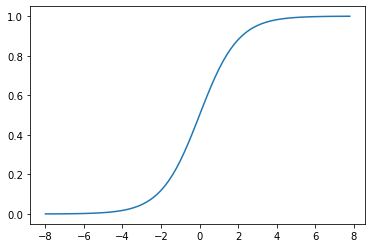

In [11]:
import matplotlib.pyplot as plt
import numpy as np
 
 
def sigmoid(x):
    # 直接返回sigmoid函数
    return 1. / (1. + np.exp(-x))
 
 
def plot_sigmoid():
    # param:起点，终点，间距
    x = np.arange(-8, 8, 0.2)
    y = sigmoid(x)
    plt.plot(x, y)
    plt.show()
 
 
if __name__ == '__main__':
    plot_sigmoid()

# PyTorch 构建模型需要 5 大步骤：

- 数据：包括数据读取，数据清洗，进行数据划分和数据预处理，比如读取图片如何预处理及数据增强。

- 模型：包括构建模型模块，组织复杂网络，初始化网络参数，定义网络层。

- 损失函数：包括创建损失函数，设置损失函数超参数，根据不同任务选择合适的损失函数。

- 优化器：包括根据梯度使用某种优化器更新参数，管理模型参数，管理多个参数组实现不同学习率，调整学习率。

- 迭代训练：组织上面 4 个模块进行反复训练。包括观察训练效果，绘制 Loss/ Accuracy 曲线，用 TensorBoard 进行可视化分析。

# 生成随机数Tensor的方法：
torch.rand()

torch.randn()

torch.normal()

torch.linespace()

均匀分布torch.rand(*sizes, out=None) → Tensor 返回一个张量，包含了从区间（0, 1)的均匀分布中抽取的一组随机数。

torch.randn(*sizes, out=None) → Tensor 返回一个张量，包含了从标准正态分布（均值为0，方差为1，即高斯白噪声）中抽取的一组随机数。张量的形状由参数sizes定义。

torch.normal(means, std, out=None) → → Tensor 返回一个张量，包含了从指定均值means和标准差std的离散正态分布中抽取的一组随机数。

torch.linspace(start, end, steps=100, out=None) → Tensor  返回一个1维张量，包含在区间start和end上均匀间隔的step个点。输出张量的长度由steps决定。

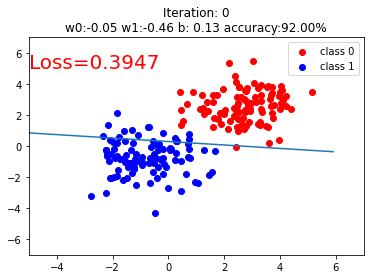

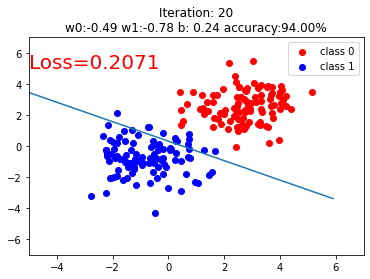

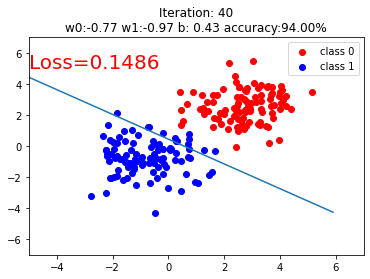

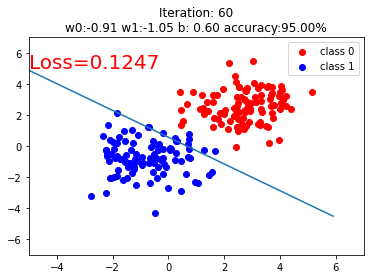

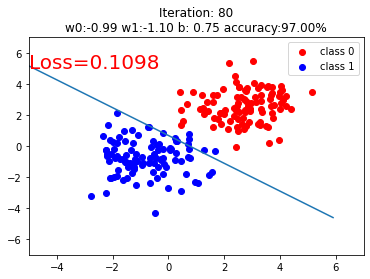

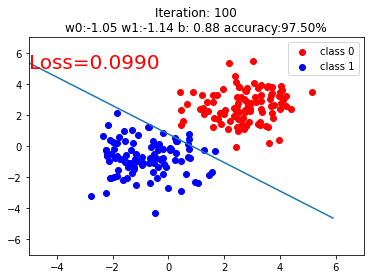

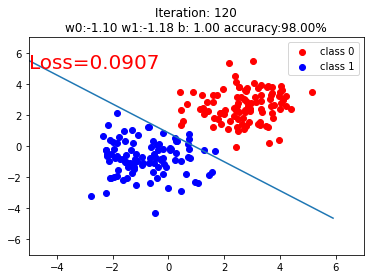

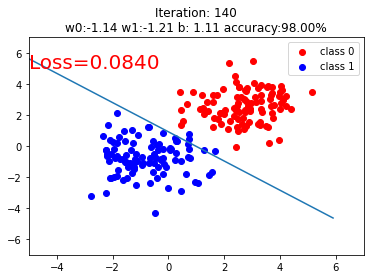

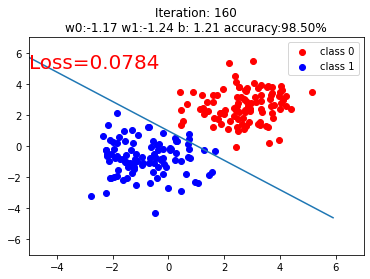

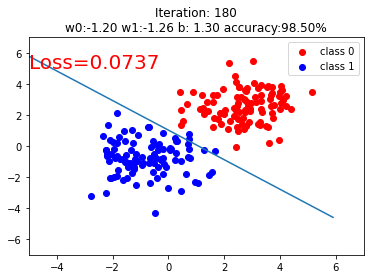

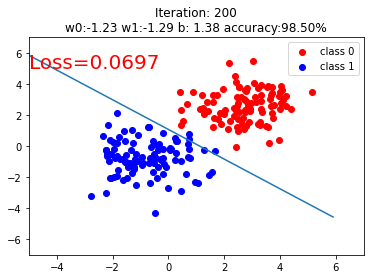

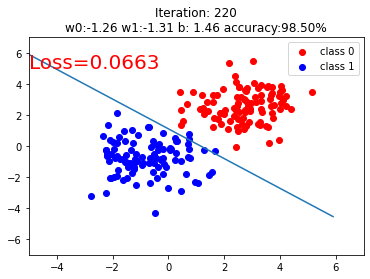

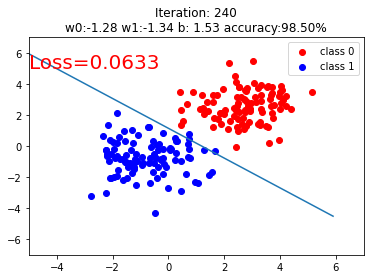

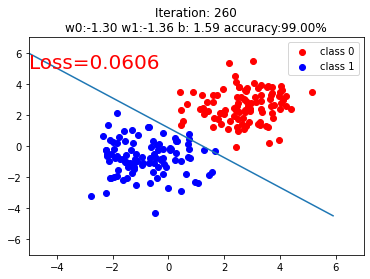

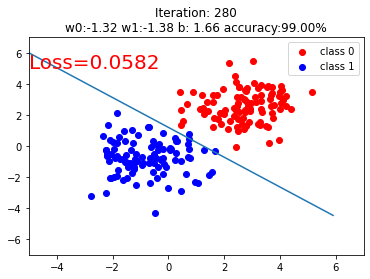

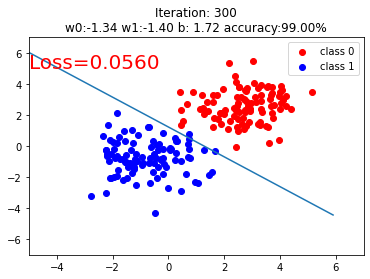

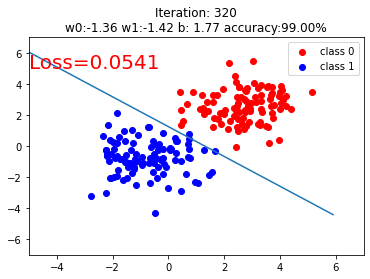

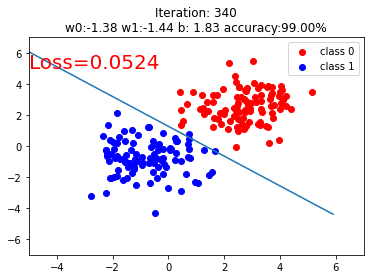

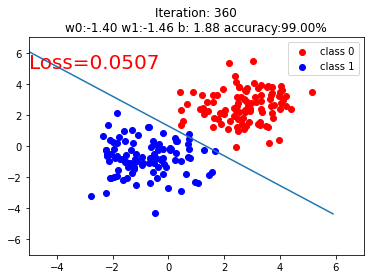

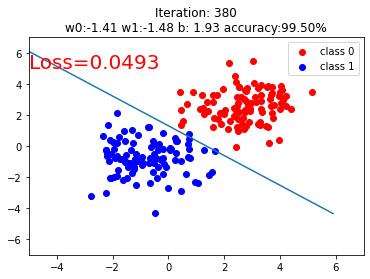

In [12]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
torch.manual_seed(10)

# ============================ step 1/5 生成数据 ============================
sample_nums = 100
mean_value = 1.7
bias = 1
n_data = torch.ones(sample_nums, 2)
# 使用正态分布随机生成样本，均值为张量，方差为标量
x0 = torch.normal(mean_value * n_data, 1) + bias      # 类别0 数据 shape=(100, 2) 随机离散正态分布，方差 1
# bais 会对张量的每一个数进行加法
# 生成对应标签
y0 = torch.zeros(sample_nums)                         # 类别0 标签 shape=(100, 1)
# 使用正态分布随机生成样本，均值为张量，方差为标量
x1 = torch.normal(-mean_value * n_data, 1) + bias     # 类别1 数据 shape=(100, 2)
# 生成对应标签
y1 = torch.ones(sample_nums)                          # 类别1 标签 shape=(100, 1)
train_x = torch.cat((x0, x1), 0)                      # 类别0 标签 shape=(200, 2)，2 表示xy轴的坐标
train_y = torch.cat((y0, y1), 0)                      # 类别0 标签 shape=(200, 1)


# ============================ step 2/5 选择模型 ============================
class LR(nn.Module):   # 继承来一个nn的类
    def __init__(self):  
        super(LR, self).__init__()  # 继承nn的__init__功能
        self.features = nn.Linear(2, 1)  # 线性输出的定义， 2，1是指维度
        self.sigmoid = nn.Sigmoid()  # 线性输出的激活函数

    def forward(self, x):
        x = self.features(x)
        x = self.sigmoid(x)
        return x

lr_net = LR()   # 实例化逻辑回归模型

# ============================ step 3/5 选择损失函数 ============================
loss_fn = nn.BCELoss()

# ============================ step 4/5 选择优化器   ============================
lr = 0.01  # 学习率
optimizer = torch.optim.SGD(lr_net.parameters(), lr=lr, momentum=0.9)

# ============================ step 5/5 模型训练 ============================
for iteration in range(1000):

    # 前向传播
    y_pred = lr_net(train_x)
    # 计算 loss
    loss = loss_fn(y_pred.squeeze(), train_y)
    # 反向传播
    loss.backward()
    # 更新参数
    optimizer.step()
    # 清空梯度
    optimizer.zero_grad()
    # 绘图
    if iteration % 20 == 0:
        mask = y_pred.ge(0.5).float().squeeze()  # 以0.5为阈值进行分类
        correct = (mask == train_y).sum()  # 计算正确预测的样本个数
        acc = correct.item() / train_y.size(0)  # 计算分类准确率

        plt.scatter(x0.data.numpy()[:, 0], x0.data.numpy()[:, 1], c='r', label='class 0')
        plt.scatter(x1.data.numpy()[:, 0], x1.data.numpy()[:, 1], c='b', label='class 1')

        w0, w1 = lr_net.features.weight[0]  # get the w0 and w1 value
        w0, w1 = float(w0.item()), float(w1.item())
        plot_b = float(lr_net.features.bias[0].item())
        plot_x = np.arange(-6, 6, 0.1)
        plot_y = (-w0 * plot_x - plot_b) / w1

        plt.xlim(-5, 7)
        plt.ylim(-7, 7)
        plt.plot(plot_x, plot_y)

        plt.text(-5, 5, 'Loss=%.4f' % loss.data.numpy(), fontdict={'size': 20, 'color': 'red'})
        plt.title("Iteration: {}\nw0:{:.2f} w1:{:.2f} b: {:.2f} accuracy:{:.2%}".format(iteration, w0, w1, plot_b, acc))
        plt.legend()
        # plt.savefig(str(iteration / 20)+".png")
        plt.show()
        plt.pause(0.5)
        # 如果准确率大于 99%，则停止训练
        if acc > 0.99:
            break

# DataLoader 与 DataSet

torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False, sampler=None, batch_sampler=None, num_workers=0, collate_fn=None, pin_memory=False, drop_last=False, timeout=0, worker_init_fn=None, multiprocessing_context=None)

功能：构建可迭代的数据装载器

dataset: Dataset 类，决定数据从哪里读取以及如何读取
batchsize: 批大小
num_works: 是否多进程读取数据
sheuffle: 每个 epoch 是否乱序
drop_last: 当样本数不能被 batchsize 整除时，是否舍弃最后一批数据


# Epoch: 所有训练样本都已经输入到模型中，称为一个 Epoch
# Iteration: 一批样本输入到模型中，称为一个 Iteration
# Batchsize: 批大小，决定一个 iteration 有多少样本，也决定了一个 Epoch 有多少个 Iteration

torch.utils.data.Dataset

功能：Dataset 是抽象类，所有自定义的 Dataset 都需要继承该类，并且重写__getitem()__方法和__len__()方法 。__getitem()__方法的作用是接收一个索引，返回索引对应的样本和标签，这是我们自己需要实现的逻辑。__len__()方法是返回所有样本的数量。

实现读取数据的 Dataset，编写一个get_img_info()方法，读取每一个图片的路径和对应的标签，组成一个元组，再把所有的元组作为 list 存放到self.data_info变量中，这里需要注意的是标签需要映射到 0 开始的整数: rmb_label = {"1": 0, "100": 1}

然后在Dataset 的初始化函数中调用get_img_info()方法。

然后在__getitem__()方法中根据index 读取self.data_info中路径对应的数据，并在这里做 transform 操作转化为tensor，返回的是样本和标签。

In [ ]:
    @staticmethod
    def get_img_info(data_dir):
        data_info = list()
        # data_dir 是训练集、验证集或者测试集的路径
        for root, dirs, _ in os.walk(data_dir):
            # 遍历类别
            # dirs ['1', '100']
            for sub_dir in dirs:
                # 文件列表
                img_names = os.listdir(os.path.join(root, sub_dir))
                # 取出 jpg 结尾的文件
                img_names = list(filter(lambda x: x.endswith('.jpg'), img_names))
                # 遍历图片
                for i in range(len(img_names)):
                    img_name = img_names[i]
                    # 图片的绝对路径
                    path_img = os.path.join(root, sub_dir, img_name)
                    # 标签，这里需要映射为 0、1 两个类别
                    label = rmb_label[sub_dir]
                    # 保存在 data_info 变量中
                    data_info.append((path_img, int(label)))
        return data_info

    def __init__(self, data_dir, transform=None):
        """
        rmb面额分类任务的Dataset
        :param data_dir: str, 数据集所在路径
        :param transform: torch.transform，数据预处理
        """
        # data_info存储所有图片路径和标签，在DataLoader中通过index读取样本
        self.data_info = self.get_img_info(data_dir)
        self.transform = transform
        
    def __getitem__(self, index):
        # 通过 index 读取样本
        path_img, label = self.data_info[index]
        # 注意这里需要 convert('RGB')
        img = Image.open(path_img).convert('RGB')     # 0~255
        if self.transform is not None:
            img = self.transform(img)   # 在这里做transform，转为tensor等等
        # 返回是样本和标签
        return img, label
    
# 返回所有样本的数量
    def __len__(self):
        return len(self.data_info) 

在train_lenet.py中，分 5 步构建模型。

第 1 步设置数据。首先定义训练集、验证集、测试集的路径，定义训练集和测试集的transforms。然后构建训练集和验证集的RMBDataset对象，把对应的路径和transforms传进去。再构建DataLoder，设置 batch_size，其中训练集设置shuffle=True，表示每个 Epoch 都打乱样本。

第 2 步构建模型，这里采用经典的 Lenet 图片分类网络。

第 3 步设置损失函数，这里使用交叉熵损失函数。

第 4 步设置优化器。这里采用 SGD 优化器。

第 5 步迭代训练模型，在每一个 epoch 里面，需要遍历 train_loader 取出数据，每次取得数据是一个 batchsize 大小。这里又分为 4 步。第 1 步进行前向传播，第 2 步进行反向传播求导，第 3 步使用optimizer更新权重，第 4 步统计训练情况。每一个 epoch 完成时都需要使用scheduler更新学习率，和计算验证集的准确率、loss。

我们可以看到每个 iteration，我们是从train_loader中取出数据的。

这里我们没有设置多进程，会执行_SingleProcessDataLoaderIter的方法。我们以_SingleProcessDataLoaderIter为例。在_SingleProcessDataLoaderIter里只有一个方法_next_data()，如下：


在该方法中，self._next_index()是获取一个 batchsize 大小的 index 列表，代码如下：

其中调用的sampler类的__iter__()方法返回 batch_size 大小的随机 index 列表。

然后再返回看 dataloader的_next_data()方法：

在第二行中调用了self._dataset_fetcher.fetch(index)获取数据。这里会调用_MapDatasetFetcher中的fetch()函数：

这里调用了self.dataset[idx]，这个函数会调用dataset.__getitem__()方法获取具体的数据，所以__getitem__()方法是我们必须实现的。我们拿到的data是一个 list，每个元素是一个 tunple，每个 tunple 包括样本和标签。所以最后要使用self.collate_fn(data)把 data 转换为两个 list，第一个 元素 是样本的 batch 形式，形状为 [16, 3, 32, 32] (16 是 batch size，[3, 32, 32] 是图片像素)；第二个元素是标签的 batch 形式，形状为 [16]。

所以在代码中，我们使用inputs, labels = data来接收数据。

In [ ]:
# 构建MyDataset实例train_data = RMBDataset(data_dir=train_dir, transform=train_transform)valid_data = RMBDataset(data_dir=valid_dir, transform=valid_transform)

# 构建DataLoder
# 其中训练集设置 shuffle=True，表示每个 Epoch 都打乱样本
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(dataset=valid_data, batch_size=BATCH_SIZE)


net = LeNet(classes=2)
net.initialize_weights()

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(net.parameters(), lr=LR, momentum=0.9)                        # 选择优化器
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)     # 设置学习率下降策略

for epoch in range(MAX_EPOCH):

    loss_mean = 0.
    correct = 0.
    total = 0.

    net.train()
    # 遍历 train_loader 取数据
    for i, data in enumerate(train_loader):

        # forward
        inputs, labels = data
        outputs = net(inputs)

        # backward
        optimizer.zero_grad()
        loss = criterion(outputs, labels)
        loss.backward()

        # update weights
        optimizer.step()

        # 统计分类情况
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).squeeze().sum().numpy()

        # 打印训练信息
        loss_mean += loss.item()
        train_curve.append(loss.item())
        if (i+1) % log_interval == 0:
            loss_mean = loss_mean / log_interval
            print("Training:Epoch[{:0>3}/{:0>3}] Iteration[{:0>3}/{:0>3}] Loss: {:.4f} Acc:{:.2%}".format(
                epoch, MAX_EPOCH, i+1, len(train_loader), loss_mean, correct / total))
            loss_mean = 0.

    scheduler.step()  # 更新学习率
    # 每个 epoch 计算验证集得准确率和loss
    ...
    ...
    
def __iter__(self):
    if self.num_workers == 0:
        return _SingleProcessDataLoaderIter(self)
    else:
        return _MultiProcessingDataLoaderIter(self)

def _next_data(self):
 index = self._next_index()  # may raise StopIteration
 data = self._dataset_fetcher.fetch(index)  # may raise StopIteration
 if self._pin_memory:
  data = _utils.pin_memory.pin_memory(data)
 return data

def _next_index(self):
    return next(self._sampler_iter)  # may raise StopIteration


def __iter__(self):
 batch = []
 for idx in self.sampler:
  batch.append(idx)
  if len(batch) == self.batch_size:
   yield batch
   batch = []
 if len(batch) > 0 and not self.drop_last:
  yield batch

def _next_data(self):
 index = self._next_index()  # may raise StopIteration
 data = self._dataset_fetcher.fetch(index)  # may raise StopIteration
 if self._pin_memory:
  data = _utils.pin_memory.pin_memory(data)
 return data

def fetch(self, possibly_batched_index):
 if self.auto_collation:
  data = [self.dataset[idx] for idx in possibly_batched_index]
 else:
  data = self.dataset[possibly_batched_index]
 return self.collate_fn(data)